<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/Unit5/SamaBhatU5proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

# Understanding The Improvement of Swimming As A Whole via GLMs

This is the same data I've used for a previous project FYI.
The Olympics and many international swimming organizations offer meets to test the fastest swimmers to break records and push boundaires. I found a dataset with the fastest 100 LCM freestyle times to analyze whether such pushes are effective by plotting swimming times (and thus speed) against the year it was swam to observe trends in the sports growth.


In [ ]:
swimming_data = "https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit4/Swimming_database_2%5B1%5D.csv"

swimming_data = pd.read_csv(swimming_data)

swimming_data

,index,Event Name,Swim time,Swim date,Event description,Team Code,Team Name,Athlete Full Name,Gender,Athlete birth date,Rank_Order,City,Country Code,Duration (hh:mm:ss:ff)
0,0,European Championships 2022,46.86,08-13-22,Men 100 Freestyle LCM Male,ROU,Romania,"POPOVICI, David",M,09-15-04,1,Rome,ITA,0:0:46:86
1,1,13th FINA World Championships 2009,46.91,07-30-09,Men 100 Freestyle LCM Male,BRA,Brazil,"CIELO FILHO, Cesar",M,01-10-87,2,Rome,ITA,0:0:46:91
2,2,French National Championships (50m),46.94,04-23-09,Men 100 Freestyle LCM Male,FRA,France,"BERNARD, Alain",M,05-01-83,3,Montpellier,FRA,0:0:46:94
3,3,18th FINA World Championships 2019,46.96,07-25-19,Men 100 Freestyle LCM Male,USA,United States of America,"DRESSEL, Caeleb",M,08-16-96,4,Gwangju,KOR,0:0:46:96
4,4,European Championships 2022,46.98,08-12-22,Men 100 Freestyle LCM Male,ROU,Romania,"POPOVICI, David",M,09-15-04,5,Rome,ITA,0:0:46:98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,5195,18th FINA World Championships 2019,16:02.10,07-23-19,Women 1500 Freestyle LCM Female,ESP,Spain,"BELMONTE, Mireia",F,11-10-90,196,Gwangju,KOR,0:16:02:10
5196,5196,European Championships 2022,16:02.15,08-15-22,Women 1500 Freestyle LCM Female,HUN,Hungary,"MIHALYVARI-FARKAS, Viktoria",F,11-26-03,197,Rome,ITA,0:16:02:15
5197,5197,13th FINA World Championships 2009,16:02.21,07-27-09,Women 1500 Freestyle LCM Female,ROU,Romania,"POTEC, Camelia",F,02-19-82,198,Rome,ITA,0:16:02:21
5198,5198,Olympic Games Tokyo 2020,16:02.26,07-26-21,Women 1500 Freestyle LCM Female,HUN,Hungary,"MIHALYVARI-FARKAS, Viktoria",F,11-26-03,199,Tokyo,JPN,0:16:02:26


In [ ]:
swimming_data = "https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit4/Swimming_database_2%5B1%5D.csv"
swimming_data = pd.read_csv(swimming_data)
swimming_data = swimming_data[swimming_data['Event description'] == 'Men 100 Freestyle LCM Male']

swimming_data = swimming_data[["Swim time", "Athlete Full Name", "Swim date"]]
swimming_data = swimming_data.rename(columns={'Swim time': 'swim_time'})

# Convert 'swim_time' to a numeric type, handling potential errors (used Gemini for this)
swimming_data['swim_time'] = pd.to_numeric(swimming_data['swim_time'], errors='coerce')
swimming_data['Swim date'] = pd.to_datetime(swimming_data['Swim date'], errors='coerce')

swimming_data['Swim_year'] = (swimming_data['Swim date'].dt.year)

# Sort the data by 'Swim_year' to ensure chronological order for plotting and modeling
swimming_data = swimming_data.sort_values(by='Swim_year').reset_index(drop=True)

swimming_data

/tmp/ipython-input-2233702861.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swimming_data['Swim date'] = pd.to_datetime(swimming_data['Swim date'], errors='coerce')


,swim_time,Athlete Full Name,Swim date,Swim_year
0,47.84,"VAN DEN HOOGENBAND, Pieter",2000-09-19,2000
1,47.86,"VAN DEN HOOGENBAND, Pieter",2002-07-31,2002
2,47.05,"SULLIVAN, Eamon",2008-08-13,2008
3,47.24,"SULLIVAN, Eamon",2008-08-11,2008
4,47.32,"SULLIVAN, Eamon",2008-08-14,2008
...,...,...,...,...
195,47.83,"DEAN, Tom",2022-07-31,2022
196,47.76,"POPOVICI, David",2022-07-05,2022
197,47.78,"GRINEV, Vladislav",2022-04-29,2022
198,47.88,"MIRESSI, Alessandro",2022-04-11,2022


<Axes: xlabel='Swim year', ylabel='swim_time'>

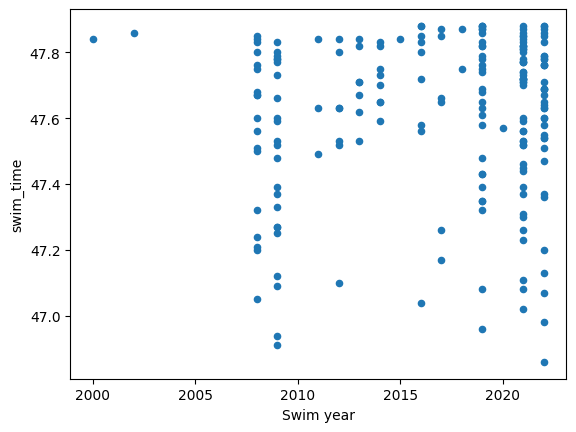

In [ ]:
swimming_data['index'] = swimming_data.index
swimming_data.plot(kind="scatter", x="Swim year", y="swim_time")

This scatterplot isn't that good. I had some difficulty finding a good parameter to use for the x axis. However, after much thought and analysis, I realized that it would be fine to sort the dates this way. I can sort of see a positive trend but let's hope the model sees what I see too.

In [ ]:
with pm.Model() as model_lb:

    #priors for the linear part of our model
    α = pm.Normal("α", mu=0, sigma=100)
    β = pm.Normal("β", mu=0, sigma=10)

    #this is the linear part of our model
    μ = pm.Deterministic("μ", α + β * swimming_data.Swim_year)

    #prior for the standard deviation of our likelihood
    #Cauchy is a T dist with nu = 1
    σ = pm.HalfCauchy("σ", 10)

    #likelihood
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=swimming_data.swim_time)

    #inference data object
    idata_lb = pm.sample()

Text(0, 0.5, 'swim time')

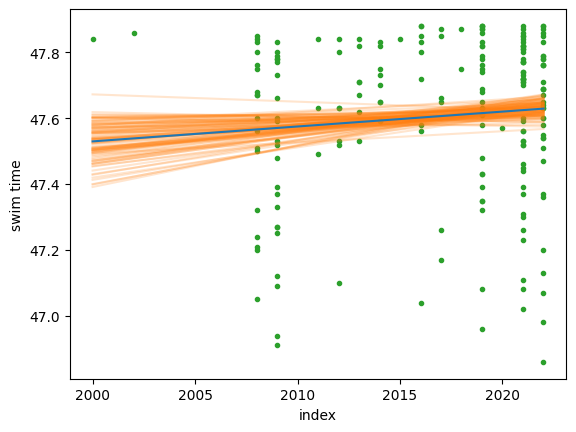

In [ ]:

#grabs 100 posterior samples
posterior = az.extract(idata_lb, num_samples=100)

# grabbing x values for graphing.
x_plot = xr.DataArray(
    np.linspace(swimming_data.Swim_year.min(), swimming_data.Swim_year.max(), 50),
    dims="plot_id"
    )

# this creates the expected line, the path we predict temperature and
#rented bike count deviates from
mean_line = posterior["α"].mean() + posterior["β"].mean() * x_plot

#These are a 50 lines that our model came up with
lines = posterior["α"] + posterior["β"] * x_plot

#set up plot
_, ax = plt.subplots()

#plots 50 other lines our model came up with.
ax.plot(x_plot, lines.T, c="C1", alpha=0.2, label="lines")

#plots the mean line
ax.plot(x_plot, mean_line, c="C0", label="mean line")

#plot the raw data
ax.plot(swimming_data.Swim_year, swimming_data.swim_time, "C2.", zorder=-3)

#label axes and create legend
ax.set_xlabel("index")
ax.set_ylabel("swim time")

So this model doesn't look too hot. There is a slight upward slope, which looks promising but this is the point at which I realized this data might not be that great. Here's why:

It would make the most sense to say the sport of swimming is "getting faster" as a whole if the mean line has a downward slope. This means that more people are getting faster. However, in this case there is an upward slope, so you might think that the sport is actually getting WORSE over time.

This goes against my gut because people are definetly getting better when I watch Olympic and World Championship races, but an upward trend can also indicate positive growth for the sport. The upward slope can also indicate that there are more consistently fast times (in the top 200 fastest times, slower than rare old times) recently than many years ago. Consistent but not exceptional beats exceptional and inconsistent any day... thus, I doubt I can draw any real conclusions from this project :(

In [ ]:
pm.sample_posterior_predictive(idata_lb, model=model_lb,  extend_inferencedata=True)

Text(0, 0.5, 'swim time')

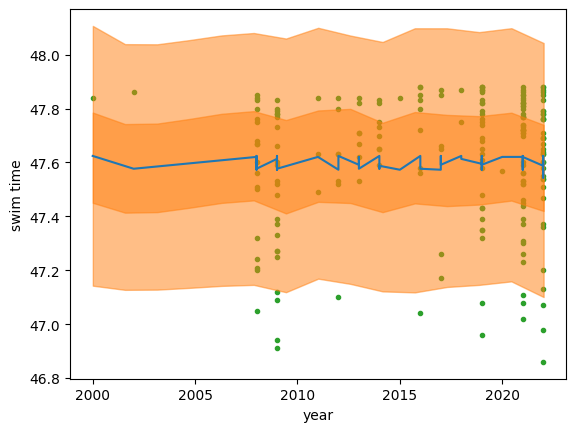

In [ ]:

#plots the posterior predictive distribution

#grabs the expected line, or line of best fit formula
mean_line = idata_lb.posterior["μ"].mean(("chain", "draw"))

#creates some x values to run through our line formula
years = np.random.normal(swimming_data.Swim_year.values, 0.01)
idx = np.argsort(years)
x = np.linspace(years.min(), years.max(), 15)

#grabs the 94% HDI and 50% HDI
y_pred_q = idata_lb.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
#sets up the HDIs for graphing
y_hat_bounds = iter(
    [
        PchipInterpolator(years[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

#plots raw data and our line of best fit
_, ax = plt.subplots()
ax.plot(swimming_data.Swim_year, swimming_data.swim_time, "C2.", zorder=-3)
ax.plot(swimming_data.Swim_year[idx], mean_line[idx], c="C0")


#graphs the 94% and 50% HDIs
for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

#labels
ax.set_xlabel("year")
ax.set_ylabel("swim time")

Again a reference of bad data. I think the model doesn't know what to make of the vertical data points. I had a lot of trouble dealing with that, which is why it looks like that. I couldn't find a solution to making the data seem more continuous. I attempted to make my x axis a number that's based on int(year+month+date), but pandas kept throwing weird errors. I decided that I should at least get nominal progress done on the other parts of the progress instead of only focusing on the pesky data wrangling. Bad choice of data on my end -- sorry about that.

<Axes: xlabel='y_pred'>

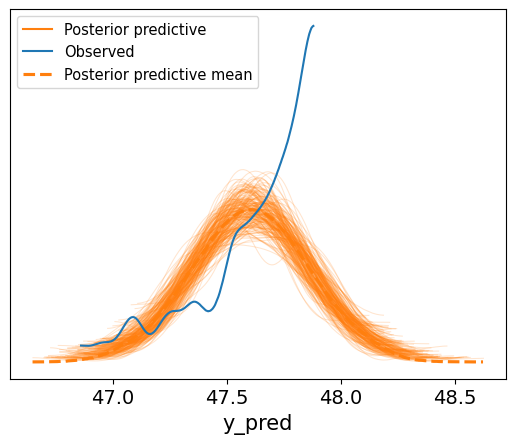

In [38]:
az.plot_ppc(idata_lb, num_pp_samples=200, colors=["C1", "C0", "C1"])

The posterior predictive does a find job matching the skews near the beginning of the observed data but loses track a lot near the middle and end. After seeing this, I think the likelihoods etc are good, but I need to make a ppm have a high kurtosis to match that high peak!

# Conclusion + Lessons

I picked a bad dataset for this. The data wrangling took too much time, and that hurt the looks of this project. GLMs are powerful predictive tools because everything is a line.

No real conclusion except saying that people are getting more consistent at swimming fast times, but it's still as rare as it was in 2009 to get a world record or top 1% time. Swimming is getting better to an extent, but I feel as if this is onlt because of the world record. There's this theory I've read about called the Bannister Effect that may explain this. "Once a single person crosses a barrier, everyone else improves."